# _Pain Level Detection_

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Import Dataset 

In [2]:
df_original = pd.read_csv("pain_dataset_200P_4hz.csv")

df = df_original.copy()
df_original

,person_ID,acc_x,acc_y,acc_z,eda,bvp,hr,temp,pain_scale
0,P001,0.2751,-0.0464,0.3049,0.7395,99.24,67.6,33.94,5
1,P001,0.2428,-0.1161,0.3641,0.7793,103.24,68.3,33.95,5
2,P001,0.0146,-0.1479,0.6552,0.8581,103.08,68.1,33.91,5
3,P001,-0.0806,-0.2144,0.6631,0.8881,104.12,66.6,33.94,5
4,P001,-0.0808,-0.1754,0.5448,0.7786,107.05,66.8,33.95,5
...,...,...,...,...,...,...,...,...,...
95995,P200,0.3618,0.0199,0.1452,5.2451,124.71,104.4,36.09,7
95996,P200,0.2842,-0.1367,0.0158,5.3054,125.71,103.4,36.09,7
95997,P200,0.3005,-0.1288,-0.1729,5.2345,125.07,103.3,36.13,7
95998,P200,0.2964,-0.1015,-0.2274,5.2046,126.12,102.7,36.19,7


## Step 3: Dataset Overview

In [3]:
print("Shape of the dataset:",df.shape)

Shape of the dataset: (96000, 9)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96000 entries, 0 to 95999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   person_ID   96000 non-null  object 
 1   acc_x       96000 non-null  float64
 2   acc_y       96000 non-null  float64
 3   acc_z       96000 non-null  float64
 4   eda         96000 non-null  float64
 5   bvp         96000 non-null  float64
 6   hr          96000 non-null  float64
 7   temp        96000 non-null  float64
 8   pain_scale  96000 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 6.6+ MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
acc_x,96000.0,0.000359,0.274042,-1.2498,-0.1828,0.00030,0.1843,1.1385
acc_y,96000.0,-0.005374,0.274731,-1.0252,-0.1904,-0.00515,0.1793,1.1719
acc_z,96000.0,0.005558,0.274240,-1.2116,-0.1785,0.00340,0.1876,1.1030
eda,96000.0,2.890202,2.151289,0.0500,0.9911,2.67410,4.4644,9.8622
bvp,96000.0,86.924307,26.516553,40.0000,64.2900,89.13000,109.3700,130.0000
hr,96000.0,79.270666,13.785112,50.0000,69.1000,79.20000,89.7250,110.0000
temp,96000.0,34.514430,1.731756,30.2500,33.3200,34.56000,35.8300,38.0000
pain_scale,96000.0,4.535000,2.137480,1.0000,3.0000,4.00000,6.0000,8.0000


In [6]:
print("Checking the missing values:")
df.isnull().sum()

Checking the missing values:


person_ID     0
acc_x         0
acc_y         0
acc_z         0
eda           0
bvp           0
hr            0
temp          0
pain_scale    0
dtype: int64

**The dataset is clean as there is no missing values**

In [7]:
print("Checking the duplicates:",df.duplicated().sum())

Checking the duplicates: 0


**There are no duplicate data in the dataset**

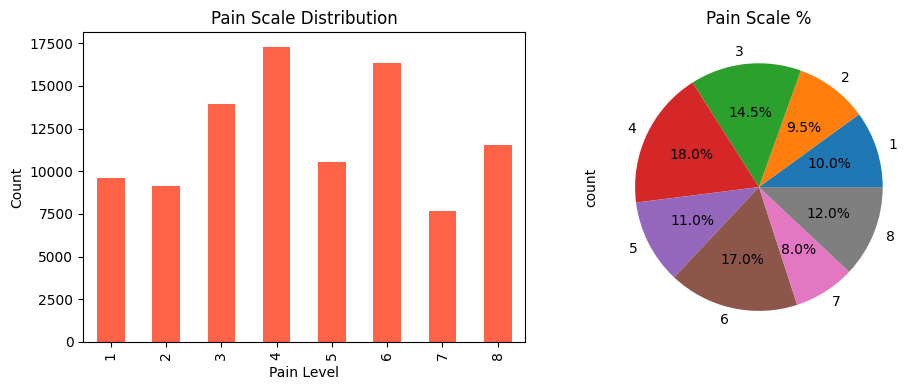

In [8]:
#Distribution of pain levels
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df['pain_scale'].value_counts().sort_index().plot(kind='bar', color='tomato')
plt.title("Pain Scale Distribution")
plt.xlabel("Pain Level")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
df['pain_scale'].value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%')
plt.title("Pain Scale %")

plt.tight_layout()
plt.show()

**The pain_scale distribution is imbalanced - pain level 4 has more samples than pain level 7**
- That means the model will be biased and do not give good performance

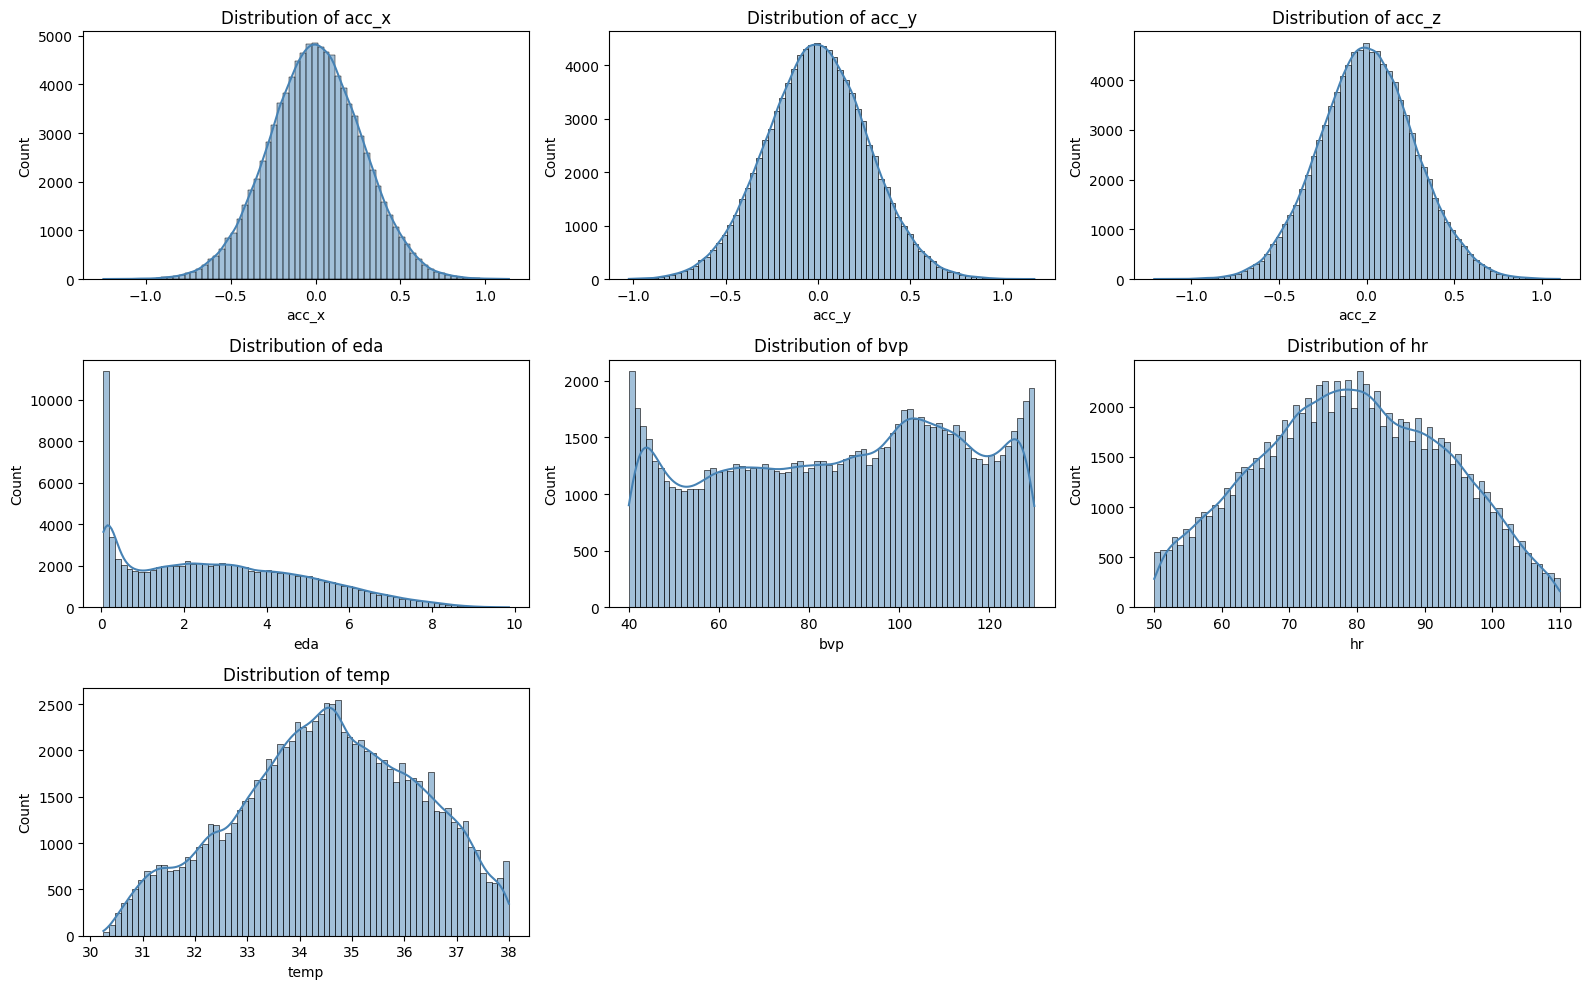

In [9]:
features = ['acc_x', 'acc_y', 'acc_z', 'eda', 'bvp', 'hr', 'temp']

plt.figure(figsize=(16, 10))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, bins=70, color='steelblue')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

C:\Users\JAYESH SAWANT\AppData\Local\Temp\ipykernel_27248\3692988085.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='pain_scale', y=col, data=df, palette='RdYlGn_r')
C:\Users\JAYESH SAWANT\AppData\Local\Temp\ipykernel_27248\3692988085.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='pain_scale', y=col, data=df, palette='RdYlGn_r')
C:\Users\JAYESH SAWANT\AppData\Local\Temp\ipykernel_27248\3692988085.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='pain_scale', y=col, data=df, palette='RdYlGn_r')
C:\Users\JAYESH SAWANT\AppDa

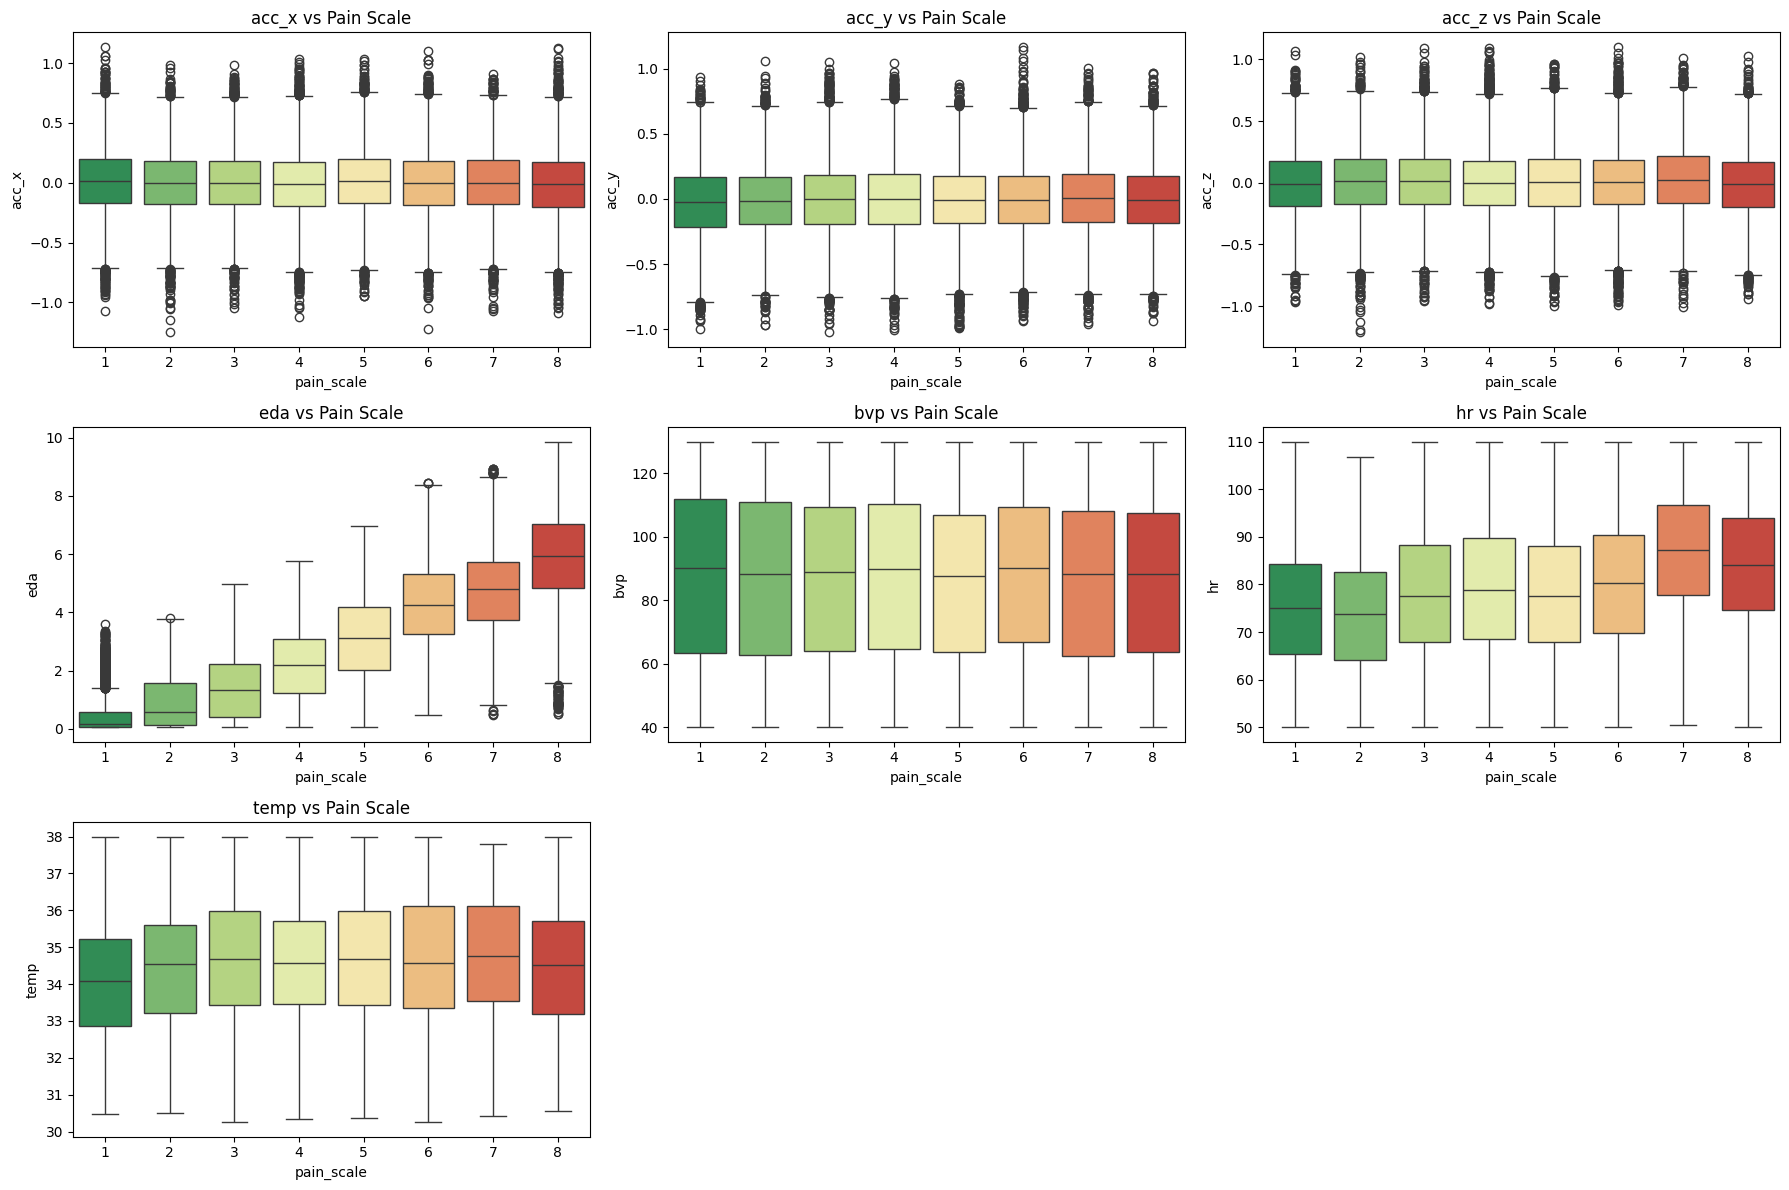

In [10]:
# Boxplot — how each feature changes across pain levels
plt.figure(figsize=(18, 12))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='pain_scale', y=col, data=df, palette='RdYlGn_r')
    plt.title(f'{col} vs Pain Scale')
    plt.tight_layout()
plt.show()

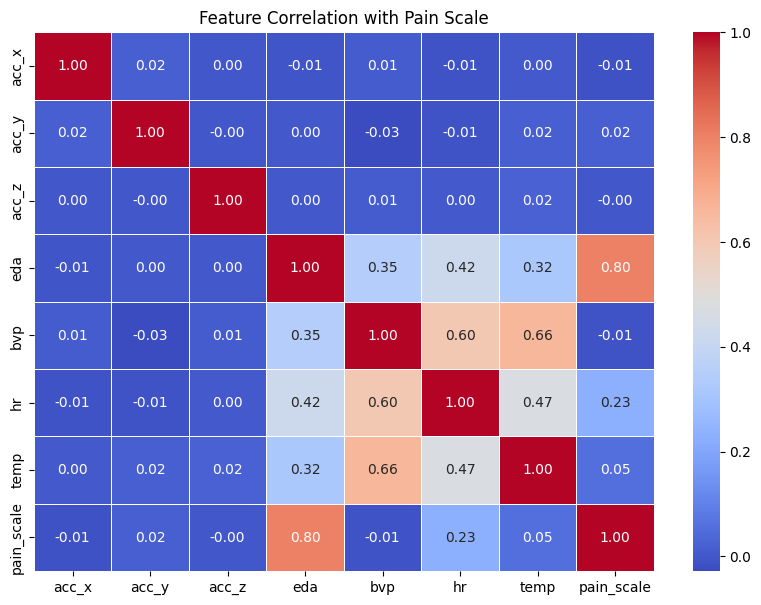


Correlation with pain_scale:
pain_scale    1.000000
eda           0.802903
hr            0.225624
temp          0.052561
acc_y         0.016491
acc_z        -0.000708
bvp          -0.011249
acc_x        -0.014897
Name: pain_scale, dtype: float64


In [11]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df[features + ['pain_scale']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation with Pain Scale")
plt.show()

# Focused: just correlation with pain_scale
print("\nCorrelation with pain_scale:")
print(corr['pain_scale'].sort_values(ascending=False))

**Both the features eda and hr have high correlation with pain_scale**
- Both are imoprtant feature for prediction

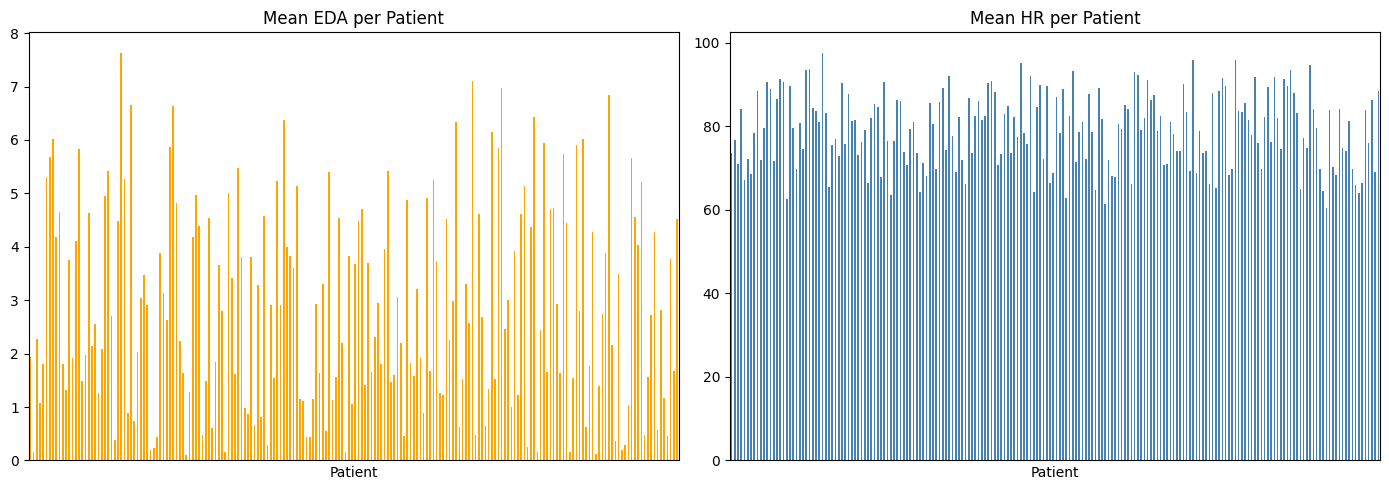

In [12]:
# Check signal variation across patients
patient_stats = df.groupby('person_ID')[features].mean()

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
patient_stats['eda'].plot(kind='bar', color='orange', figsize=(14, 5))
plt.title("Mean EDA per Patient")
plt.xlabel("Patient")
plt.xticks([])

plt.subplot(1, 2, 2)
patient_stats['hr'].plot(kind='bar', color='steelblue')
plt.title("Mean HR per Patient")
plt.xlabel("Patient")
plt.xticks([])

plt.tight_layout()
plt.show()

C:\Users\JAYESH SAWANT\AppData\Local\Temp\ipykernel_27248\1738559224.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='pain_scale', y='acc_mag', data=df, palette='Blues')


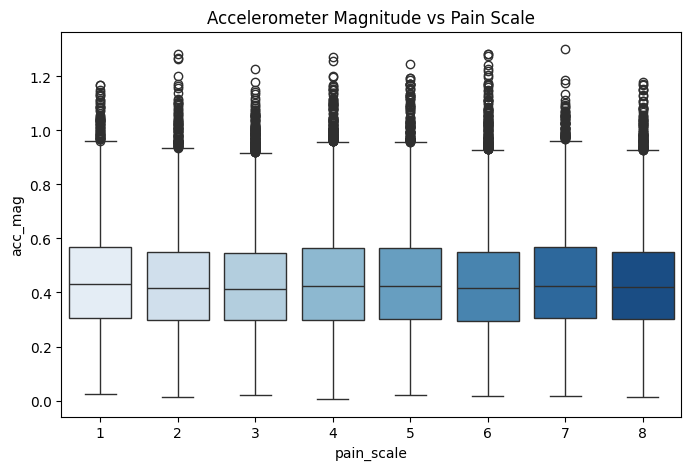

acc_mag correlation with pain: -0.005793389531906127


In [13]:
# Add magnitude
df['acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)

# Compare acc_mag vs pain_scale
plt.figure(figsize=(8, 5))
sns.boxplot(x='pain_scale', y='acc_mag', data=df, palette='Blues')
plt.title("Accelerometer Magnitude vs Pain Scale")
plt.show()

# Check its correlation
print("acc_mag correlation with pain:", df['acc_mag'].corr(df['pain_scale']))

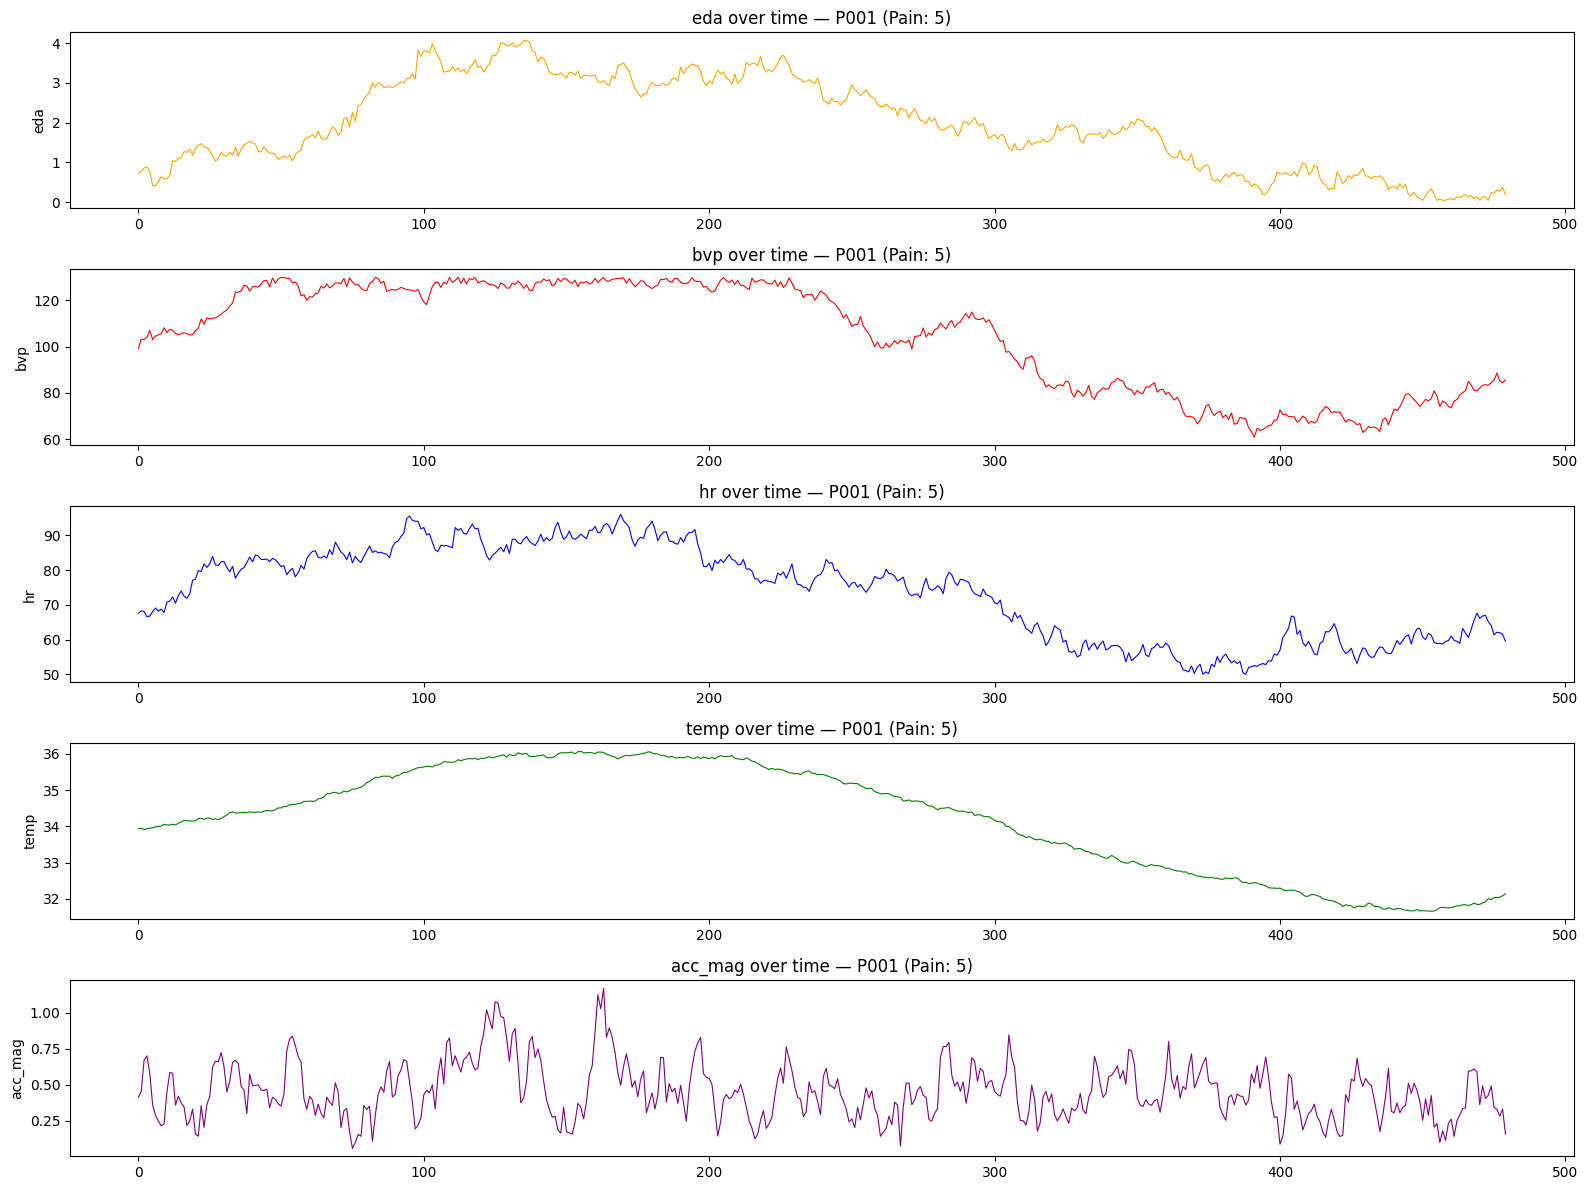

In [14]:
# Pick one patient and visualize signals over time
p1 = df[df['person_ID'] == 'P001'].reset_index(drop=True)

plt.figure(figsize=(16, 12))
signals = ['eda', 'bvp', 'hr', 'temp', 'acc_mag']
colors  = ['orange', 'red', 'blue', 'green', 'purple']

for i, (sig, col) in enumerate(zip(signals, colors), 1):
    plt.subplot(5, 1, i)
    plt.plot(p1[sig], color=col, linewidth=0.8)
    plt.ylabel(sig)
    plt.title(f'{sig} over time — P001 (Pain: {p1["pain_scale"].iloc[0]})')

plt.tight_layout()
plt.show()

pain_group
Medium (4-6)    44160
Low (1-3)       32640
High (7-8)      19200
Name: count, dtype: int64


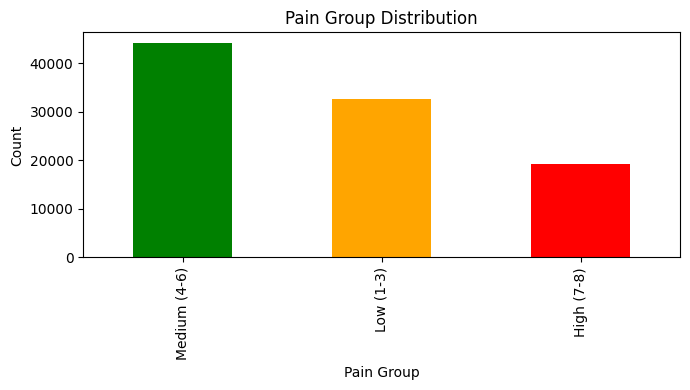

In [15]:
# Based on your EDA findings, group pain into categories
df['pain_group'] = pd.cut(
    df['pain_scale'],
    bins=[0, 3, 6, 8],
    labels=['Low (1-3)', 'Medium (4-6)', 'High (7-8)']
)

print(df['pain_group'].value_counts())

plt.figure(figsize=(7, 4))
df['pain_group'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title("Pain Group Distribution")
plt.xlabel("Pain Group")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Step 4: Evaluating the Models

In [16]:
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

### Load Dataset

In [17]:
df = pd.read_csv("pain_dataset_200P_4hz.csv")
df

,person_ID,acc_x,acc_y,acc_z,eda,bvp,hr,temp,pain_scale
0,P001,0.2751,-0.0464,0.3049,0.7395,99.24,67.6,33.94,5
1,P001,0.2428,-0.1161,0.3641,0.7793,103.24,68.3,33.95,5
2,P001,0.0146,-0.1479,0.6552,0.8581,103.08,68.1,33.91,5
3,P001,-0.0806,-0.2144,0.6631,0.8881,104.12,66.6,33.94,5
4,P001,-0.0808,-0.1754,0.5448,0.7786,107.05,66.8,33.95,5
...,...,...,...,...,...,...,...,...,...
95995,P200,0.3618,0.0199,0.1452,5.2451,124.71,104.4,36.09,7
95996,P200,0.2842,-0.1367,0.0158,5.3054,125.71,103.4,36.09,7
95997,P200,0.3005,-0.1288,-0.1729,5.2345,125.07,103.3,36.13,7
95998,P200,0.2964,-0.1015,-0.2274,5.2046,126.12,102.7,36.19,7


In [18]:
print("Shape:",df.shape)
df.head()

Shape: (96000, 9)


,person_ID,acc_x,acc_y,acc_z,eda,bvp,hr,temp,pain_scale
0,P001,0.2751,-0.0464,0.3049,0.7395,99.24,67.6,33.94,5
1,P001,0.2428,-0.1161,0.3641,0.7793,103.24,68.3,33.95,5
2,P001,0.0146,-0.1479,0.6552,0.8581,103.08,68.1,33.91,5
3,P001,-0.0806,-0.2144,0.6631,0.8881,104.12,66.6,33.94,5
4,P001,-0.0808,-0.1754,0.5448,0.7786,107.05,66.8,33.95,5


### Feature Engineering

In [19]:
# Magnitude feature
df['acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)

# Rolling features (EDA & HR trends)
df['eda_mean'] = df['eda'].rolling(window=20).mean()
df['eda_std']  = df['eda'].rolling(window=20).std()
df['hr_mean']  = df['hr'].rolling(window=20).mean()
df['hr_std']   = df['hr'].rolling(window=20).std()

# Drop NaN rows from rolling
df.dropna(inplace=True)
print("Shape after feature engineering:",df.shape)

Shape after feature engineering: (95981, 14)


### Create Target (3-Class)

In [20]:
df['pain_group'] = pd.cut(
    df['pain_scale'],
    bins=[0,3,6,8],
    labels=['Low','Medium','High']
)
print("Class Distribution:")
print(df['pain_group'].value_counts())

Class Distribution:
pain_group
Medium    44141
Low       32640
High      19200
Name: count, dtype: int64


In [21]:
df

,person_ID,acc_x,acc_y,acc_z,eda,bvp,hr,temp,pain_scale,acc_mag,eda_mean,eda_std,hr_mean,hr_std,pain_group
19,P001,0.2460,0.1759,0.1331,1.1829,105.21,77.1,34.15,5,0.330412,0.860790,0.291135,70.275,2.787920,Medium
20,P001,-0.0281,0.1351,0.0750,1.3542,106.99,77.4,34.15,5,0.157056,0.891525,0.309523,70.765,3.132894,Medium
21,P001,-0.0774,-0.0044,0.1196,1.4339,107.93,79.9,34.22,5,0.142528,0.924255,0.330902,71.345,3.678740,Medium
22,P001,-0.2129,0.2459,-0.1412,1.4735,112.03,79.6,34.22,5,0.354585,0.955025,0.352345,71.920,4.027092,Medium
23,P001,-0.1065,0.1475,0.0918,1.3900,109.72,81.8,34.19,5,0.203779,0.980120,0.364974,72.680,4.388334,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95995,P200,0.3618,0.0199,0.1452,5.2451,124.71,104.4,36.09,7,0.390357,5.567925,0.160491,100.250,2.693950,High
95996,P200,0.2842,-0.1367,0.0158,5.3054,125.71,103.4,36.09,7,0.315763,5.556855,0.170783,100.545,2.699995,High
95997,P200,0.3005,-0.1288,-0.1729,5.2345,125.07,103.3,36.13,7,0.369843,5.542585,0.185337,100.775,2.730312,High
95998,P200,0.2964,-0.1015,-0.2274,5.2046,126.12,102.7,36.19,7,0.387125,5.529380,0.199728,100.825,2.757168,High


### Features and Target

In [22]:
X = df.drop(columns=['person_ID','pain_scale','pain_group'])
y = df['pain_group']

### Encode Target

In [23]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("\nLabel Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


Label Mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


### Splitting the dataset

In [24]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)
print("Train size:",X_train.shape)
print("Test size:",X_test.shape)

Train size: (76784, 12)
Test size: (19197, 12)


### Scale Feature

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train scaled:",X_train_scaled)
print("Test scaled:",X_test_scaled)

Train scaled: [[ 0.98455715 -0.74214182 -0.07835252 ...  0.37882184  0.88456936
   0.02565735]
 [-0.90866618  1.47336872 -0.12207541 ...  0.42363421 -0.14855565
   0.54182735]
 [-0.50151746 -0.63936604 -0.99762629 ... -0.47045053  0.04222661
  -0.58486661]
 ...
 [ 1.86009092 -1.10841721 -0.13992892 ... -0.06314008  0.56622702
  -0.98115091]
 [-0.39763439  0.03159216  1.37944152 ...  0.42469668  0.42193166
  -0.52606313]
 [-0.71766713  0.52469723 -1.56456644 ...  0.17210052 -1.30849694
   0.25937596]]
Test scaled: [[ 0.79939014  1.96465153  0.6026315  ... -0.37860371  1.04374052
   0.19676409]
 [-0.8401398   0.72040856 -0.41465442 ... -0.12802728 -0.62086262
  -0.49549653]
 [-0.64476674 -0.13386956 -0.83038624 ...  0.86700738 -1.04147615
  -0.83136905]
 ...
 [-0.06593758 -2.00642971  0.49441735 ... -0.32376243  1.26353062
  -0.03442508]
 [-0.11696786  1.22954958 -0.48133183 ...  3.61716861  0.63986228
   1.36374066]
 [-0.2711522  -1.2057262  -1.28801916 ... -0.26510767 -1.37952893
  -0.

## Model 1: Logistic Regression

In [26]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    multi_class = 'multinomial',  
    max_iter=1000,
    random_state=42,
    C=1.0,
    solver='lbfgs'
)

#Train Model
lr_model.fit(X_train_scaled,y_train)

C:\Users\JAYESH SAWANT\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'multinomial'


In [27]:
#Predict the model
y_pred_lr = lr_model.predict(X_test_scaled)

In [28]:
lr_acc = accuracy_score(y_test,y_pred_lr)
print(f"Model Accuracy:{lr_acc*100:.2f}%")

Model Accuracy:74.85%


In [29]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr,target_names=le.classes_))


Classification Report:
              precision    recall  f1-score   support

        High       0.75      0.70      0.72      3840
         Low       0.78      0.80      0.79      6528
      Medium       0.73      0.73      0.73      8829

    accuracy                           0.75     19197
   macro avg       0.75      0.74      0.75     19197
weighted avg       0.75      0.75      0.75     19197



In [30]:
print("\nConfusion matrix:")
print(confusion_matrix(y_test,y_pred_lr))


Confusion matrix:
[[2669   15 1156]
 [   3 5235 1290]
 [ 895 1470 6464]]


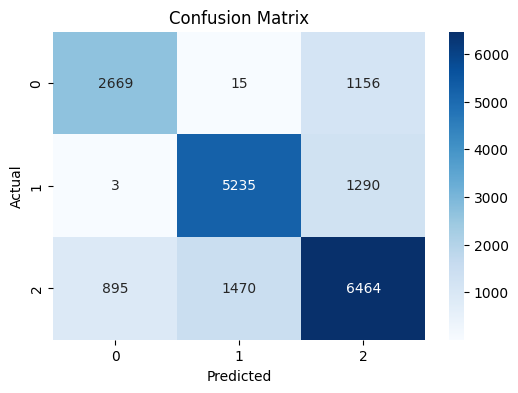

In [31]:
cm = confusion_matrix(y_test,y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Model 2: Random Forest (Better Accuracy)

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,     # number of trees
    max_depth=None,       # let trees grow fully
    min_samples_split=2,
    n_jobs=-1,            # use all CPU cores
    random_state=42
)

#Train Model
rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
#Predict the Model
y_pred_rf = rf_model.predict(X_test_scaled)

In [34]:
rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"Model Accuracy: {rf_acc*100:.2f}%")

Model Accuracy: 96.50%


In [35]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,target_names=le.classes_))


Classification Report:
              precision    recall  f1-score   support

        High       0.98      0.94      0.96      3840
         Low       0.97      0.97      0.97      6528
      Medium       0.95      0.97      0.96      8829

    accuracy                           0.96     19197
   macro avg       0.97      0.96      0.96     19197
weighted avg       0.97      0.96      0.96     19197



In [36]:
print("\nConfusion matrix:")
print(confusion_matrix(y_test,y_pred_rf))


Confusion matrix:
[[3621    5  214]
 [   2 6328  198]
 [  69  184 8576]]


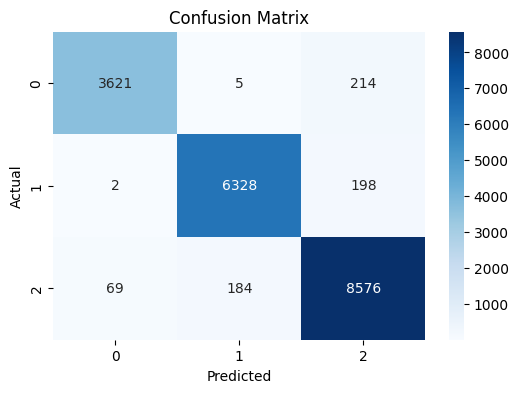

In [37]:
cm = confusion_matrix(y_test,y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

<Figure size 800x400 with 0 Axes>

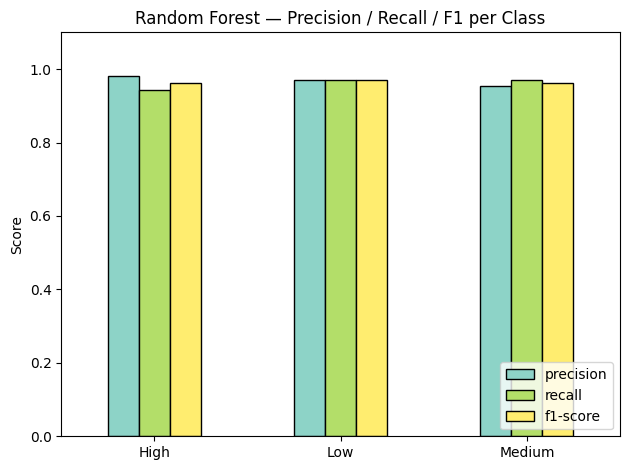

In [38]:
report_rf = classification_report(y_test, y_pred_rf,
            target_names=le.classes_, output_dict=True)
report_df_rf = pd.DataFrame(report_rf).T.iloc[:3]

plt.figure(figsize=(8, 4))
report_df_rf[['precision','recall','f1-score']].plot(
    kind='bar', colormap='Set3', edgecolor='black')
plt.title("Random Forest — Precision / Recall / F1 per Class")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Compare Both the Models

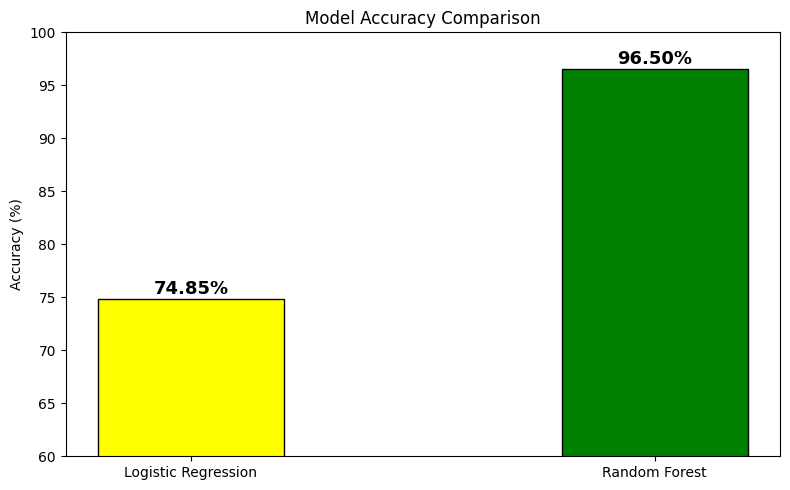

In [39]:
#Accuracy Bar
results = {
    'Logistic Regression': lr_acc,
    'Random Forest'      : rf_acc
}

plt.figure(figsize=(8, 5))
bars = plt.bar(results.keys(),
               [v*100 for v in results.values()],
               color=['yellow', 'green'],
               edgecolor='black', width=0.4)
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val*100:.2f}%', ha='center',
             fontsize=13, fontweight='bold')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(60, 100)
plt.tight_layout()
plt.show()

In [40]:
print("\n Final Summary:")
print(f"{'Model':<25} {'Accuracy':>10}")
print("-" * 37)
for name, acc in results.items():
    print(f"{name:<25} {acc*100:>9.2f}%")


 Final Summary:
Model                       Accuracy
-------------------------------------
Logistic Regression           74.85%
Random Forest                 96.50%


In [41]:
import pickle
 
# Save the Random Forest model
with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)
 
# Save the StandardScaler (fitted on training data)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
 
print("rf_model.pkl saved")
print("scaler.pkl saved")
print("Both files are now in the same folder as your notebook.")

rf_model.pkl saved
scaler.pkl saved
Both files are now in the same folder as your notebook.
